# Exploitation de données électorales avec Python

Antoine Rustenholz, Aziz Seghaier, Jasmin Neveu
31.04.2026

In [2]:
import pandas as pd
df = pd.read_csv(
 'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
)


/tmp/ipykernel_86386/192654150.py:2: DtypeWarning: Columns (0: prenom) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


## 1. Explorations générales

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 1
</div>
</div>
<div class="callout-body-container callout-body">

Créer ou mettre à jour les variables suivantes:

-   `code_commune`: En utilisant la variable déjà existante et le département, remplacer la valeur `code_commune` pour constituer un vrai code commune. Par exemple, pour Montrouge, vous devriez obtenir 92049.

-   `candidat`: créer une colonne avec le prenom et le nom mis ensemble, en n’oubliant pas de mettre un espace. Ne pas éliminer les bulletins abstentions, blancs ou nuls, nous allons les exploiter ultérieurement.

</div>
</div>

In [3]:
# Pour créer un vrai code commune, il suffit de concaténer les codes du départements et de la commune
# en ajoutant des zéros afin d'avoir toujours un code à 5 chiffres.
df['code_commune'] = (
    df['code_departement'].astype(str).str.zfill(2) +
    df['code_commune'].astype(str).str.zfill(3)
)

# On fait juste attentionau valeurs manquantes dans la colonne prenom pour les votes non exprimés.
df['candidat'] = (
    df['prenom'].fillna('') + ' ' + df['nom']
)

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 2
</div>
</div>
<div class="callout-body-container callout-body">

Compléter la phrase suivante grâce à Python:
En 2022, il y avait XXXXX candidats à l’élection présidentielle.
*Note: Attention aux votes non exprimés et aux abstentions*

</div>
</div>

In [4]:
# Il suffit de compter le nombre de valeurs différentes pour candidats en supprimant les abstentions, les votes blancs et nuls.
f"En 2022, il y avait {df['candidat'].nunique()-3} candidats à l'élection présidentielle."

"En 2022, il y avait 12 candidats à l'élection présidentielle."

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 3
</div>
</div>
<div class="callout-body-container callout-body">

Calculer les scores nationaux de chaque candidat. Représenter dans ce tableau, pour chaque candidat, le nombre de voix et le pourcatage des votes exprimés (c’est-à-dire en retirant abstentions et votes non exprimés).
Représenter cela dans un *dataframe* ou, pour avoir tous les points, dans un tableau mis en forme via `great_tables` (il n’est pas obligatoire d’aller aussi loin dans la mise en forme mais essayez d’obtenir un beau tableau tout de même).
*Note: vous pouvez contrôler vos résultats obtenus avec cette page.*

</div>
</div>

In [5]:
# Création d'une table auxiliaire
resultats = (
    df[['candidat', 'voix']]
    .groupby('candidat', as_index = False).sum()
)

# Suppression des non-candidats
resultats = resultats[~resultats['candidat'].isin([' abstentions', ' nuls', ' blancs'])]

# Calcul du nombre total de voix exprimées
nombre_total = resultats['voix'].sum()

# Création de la variable score
resultats['score'] = resultats['voix'] / nombre_total

# Tri
resultats = resultats.sort_values('voix', ascending=False)


# Génération du tableau
from great_tables import GT

(
    GT(resultats)
    .tab_header(
        title = "Elections présidentielles 2022",
        subtitle = "Résultats du premier tour (10 avril 2022)"
    )
    .cols_label( # Renommage des colonnes
        candidat = "Candidat",
        voix = "Nombre votes (total)",
        score = "Score (% votes exprimés)"
    )
    .fmt_number( # Formatage des nombres de voix
        columns = "voix",
        decimals = 0,
        sep_mark = ' '
    )
    .fmt_percent( # Formatage du score en pourcentage
        columns = "score",
        decimals = 2
    )
)

GT(_tbl_data=                 candidat     voix     score
4         Emmanuel MACRON  9783058  0.278458
8           Marine LE PEN  8133828  0.231516
7      Jean-Luc MÉLENCHON  7712520  0.219524
14           Éric ZEMMOUR  2485226  0.070738
12       Valérie PÉCRESSE  1679001  0.047790
13          Yannick JADOT  1627853  0.046334
6           Jean LASSALLE  1101387  0.031349
5          Fabien ROUSSEL   802422  0.022840
10  Nicolas DUPONT-AIGNAN   725176  0.020641
3            Anne HIDALGO   616478  0.017547
11        Philippe POUTOU   268904  0.007654
9        Nathalie ARTHAUD   197094  0.005610, _body=<great_tables._gt_data.Body object at 0x7f6d95bff380>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='voix', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='score', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f6d95bff0e0>, _spanners=Spanners([]), _heading=Heading(title='Elections présidentielles 2022', subtitle='Résultats du premier tour (10 avril 2022)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f6d95bff770>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f6d95bf3750>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f6d95bff8c0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f6d95bff620>, <great_tables._gt_data.FormatInfo object at 0x7f6d95bf3610>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_

## 2. Comparaison des scores départements aux moyennes nationales.

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 4
</div>
</div>
<div class="callout-body-container callout-body">

Créer un *dataframe* nommé `score_departements` stockant, pour chaque département, le nombre de vote obtenu pour chaque candidat et le score (en %).

</div>
</div>

In [16]:
df_exprimes = df[~df['candidat'].isin([' abstentions', ' nuls', ' blancs'])].copy()

votes_par_dept = (
    df_exprimes
    .groupby(['code_departement', 'candidat'], as_index=False)['voix']
    .sum()
)

score_departements = votes_par_dept.pivot(
    index='code_departement',
    columns='candidat',
    values='voix'
).fillna(0).reset_index()

candidats_liste = [col for col in score_departements.columns if col != 'code_departement']
score_departements['total_dept'] = score_departements[candidats_liste].sum(axis=1)

for candidat in candidats_liste:
    score_departements[f'{candidat}_score'] = (
        score_departements[candidat] / score_departements['total_dept']
    )

score_departements = score_departements.drop(columns=['total_dept'])

score_cols = ['code_departement'] + [f'{c}_score' for c in candidats_liste]
df_display = score_departements[score_cols].copy()
df_display.columns = ['Département'] + candidats_liste

GT(df_display.head(20)).tab_header(
    title="Scores par département",
    subtitle="Premier tour 2022"
)

GT(_tbl_data=   Département  Anne HIDALGO  Emmanuel MACRON  Fabien ROUSSEL  Jean LASSALLE  \
0           01      0.016948         0.276875        0.017831       0.032658   
1           02      0.011220         0.220872        0.022448       0.024329   
2           03      0.017639         0.267301        0.043661       0.041849   
3           04      0.014439         0.215136        0.028144       0.044568   
4           05      0.016919         0.237804        0.022323       0.044889   
5           06      0.009689         0.250024        0.015853       0.022848   
6           07      0.021267         0.230247        0.028988       0.045859   
7           08      0.012999         0.236352        0.022466       0.030492   
8           09      0.034982         0.197058        0.029453       0.082134   
9           10      0.011492         0.256037        0.020672       0.025302   
10          11      0.029027         0.202913        0.026466       0.058289   
11          12      0.026155         0.277527        0.026419       0.086746   
12          13      0.011659         0.227081        0.024087       0.024049   
13          14      0.017730         0.311643        0.022725       0.025415   
14          15      0.020544         0.284193        0.028331       0.077728   
15          16      0.020777         0.275741        0.027893       0.044024   
16          17      0.017401         0.288664        0.025381       0.036377   
17          18      0.016103         0.270954        0.035812       0.034230   
18          19      0.025281         0.232293        0.044123       0.071367   
19          21      0.018129         0.285536        0.020234       0.028941   

    Jean-Luc MÉLENCHON  Marine LE PEN  Nathalie ARTHAUD  \
0             0.173657       0.260507          0.004979   
1             0.154863       0.392470          0.007666   
2             0.166777       0.270576          0.007308   
3             0.226058       0.269024          0.005223   
4             0.228654       0.228399          0.004963   
5             0.165263       0.266510          0.002912   
6             0.217474       0.251778          0.006189   
7             0.166356       0.360187          0.008071   
8             0.260708       0.239444          0.004547   
9             0.150217       0.329498          0.006715   
10            0.197900       0.301408          0.004830   
11            0.191537       0.201033          0.005231   
12            0.235937       0.262490          0.003547   
13            0.191466       0.237614          0.007138   
14            0.146921       0.244830          0.006300   
15            0.193625       0.261759          0.006846   
16            0.181779       0.253231          0.005913   
17            0.173802       0.278896          0.008123   
18            0.194467       0.222006          0.006206   
19            0.190543       0.244425          0.006278   

    Nicolas DUPONT-AIGNAN  Philippe POUTOU  Valérie PÉCRESSE  Yannick JADOT  \
0                0.027019         0.006522          0.052765       0.047573   
1                0.021778         0.007967          0.041074       0.026608   
2                0.022672         0.008083          0.055492       0.032169   
3                0.025899         0.008947          0.039655       0.040928   
4                0.024839         0.009289          0.052311       0.058132   
5                0.023815         0.005349          0.055944       0.041831   
6                0.025013         0.009225          0.048499       0.043376   
7                0.022078         0.008302          0.041482       0.025729   
8                0.017676         0.007884          0.029704       0.032932   
9                0.026498         0.007096          0.059618       0.030861   
10               0.019800         0.008229          0.034600       0.029761   
11               0.020345         0.007923          0.058443       0.039473   
12               0.019880         0.005

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 5
</div>
</div>
<div class="callout-body-container callout-body">

Refaire le lien avec le niveau national pour comparer le score départemental avec le score national. Nommer ce *dataframe* `score_departements`, nous allons le réutiliser par la suite.

</div>
</div>

In [ ]:
scores_nationaux = resultats.set_index('candidat')['score'].to_dict()
for candidat in candidats_liste:
    score_departements[f'{candidat}_score_national'] = scores_nationaux.get(candidat, 0)
score_cols = ['code_departement'] + [f'{c}_score' for c in candidats_liste]
national_cols = [f'{c}_score_national' for c in candidats_liste]
df_display = score_departements[score_cols + national_cols].head(20).copy()
new_cols = ['Département'] + [f'{c} (%)' for c in candidats_liste] + \
           [f'{c} (%) nat.' for c in candidats_liste]
df_display.columns = new_cols
GT(df_display).tab_header(
    title="Comparaison scores départementaux et nationaux",
    subtitle="Premier tour 2022"
)

GT(_tbl_data=   Département  Anne HIDALGO (%)  Emmanuel MACRON (%)  Fabien ROUSSEL (%)  \
0           01          0.016948             0.276875            0.017831   
1           02          0.011220             0.220872            0.022448   
2           03          0.017639             0.267301            0.043661   
3           04          0.014439             0.215136            0.028144   
4           05          0.016919             0.237804            0.022323   
5           06          0.009689             0.250024            0.015853   
6           07          0.021267             0.230247            0.028988   
7           08          0.012999             0.236352            0.022466   
8           09          0.034982             0.197058            0.029453   
9           10          0.011492             0.256037            0.020672   
10          11          0.029027             0.202913            0.026466   
11          12          0.026155             0.277527            0.026419   
12          13          0.011659             0.227081            0.024087   
13          14          0.017730             0.311643            0.022725   
14          15          0.020544             0.284193            0.028331   
15          16          0.020777             0.275741            0.027893   
16          17          0.017401             0.288664            0.025381   
17          18          0.016103             0.270954            0.035812   
18          19          0.025281             0.232293            0.044123   
19          21          0.018129             0.285536            0.020234   

    Jean LASSALLE (%)  Jean-Luc MÉLENCHON (%)  Marine LE PEN (%)  \
0            0.032658                0.173657           0.260507   
1            0.024329                0.154863           0.392470   
2            0.041849                0.166777           0.270576   
3            0.044568                0.226058           0.269024   
4            0.044889                0.228654           0.228399   
5            0.022848                0.165263           0.266510   
6            0.045859                0.217474           0.251778   
7            0.030492                0.166356           0.360187   
8            0.082134                0.260708           0.239444   
9            0.025302                0.150217           0.329498   
10           0.058289                0.197900           0.301408   
11           0.086746                0.191537           0.201033   
12           0.024049                0.235937           0.262490   
13           0.025415                0.191466           0.237614   
14           0.077728                0.146921           0.244830   
15           0.044024                0.193625           0.261759   
16           0.036377                0.181779           0.253231   
17           0.034230                0.173802           0.278896   
18           0.071367                0.194467           0.222006   
19           0.028941                0.190543           0.244425   

    Nathalie ARTHAUD (%)  Nicolas DUPONT-AIGNAN (%)  Philippe POUTOU (%)  ...  \
0               0.004979                   0.027019             0.006522  ...   
1               0.007666                   0.021778             0.007967  ...   
2               0.007308                   0.022672             0.008083  ...   
3               0.005223                   0.025899             0.008947  ...   
4               0.004963                   0.024839             0.009289  ...   
5               0.002912                   0.023815             0.005349  ...   
6               0.006189                   0.025013             0.009225  ...   
7               0.008071                   0.022078             0.008302  ...   
8               0.004547                   0.017676             0.007884  ...   
9               0.006715                   0.026498             0.007096  ...   
10              0.004830                   0.0198

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 6
</div>
</div>
<div class="callout-body-container callout-body">

Créer une variable `surrepresentation` qui compare, en relatif, les scores nationaux et départementaux.
Par exemple, si un candidat a un score de 30% dans un département mais de 15% ailleurs, la valeur de `surrepresentation` sera égale à 100 (%).


</div>
</div>

In [19]:
for candidat in candidats_liste:
    score_dep = score_departements[f'{candidat}_score']
    score_nat = score_departements[f'{candidat}_score_national']
    score_departements[f'{candidat}_surrepresentation'] = (
        (score_dep - score_nat) / score_nat * 100
    )

surrep_cols = ['code_departement'] + [f'{c}_surrepresentation' for c in candidats_liste]
df_surrep = score_departements[surrep_cols].copy()
df_surrep.columns = ['Département'] + candidats_liste

GT(df_surrep.head(20)).tab_header(
    title="Surréprésentation par département",
    subtitle="Écart relatif au score national (%) - Premier tour 2022"
)

GT(_tbl_data=   Département  Anne HIDALGO  Emmanuel MACRON  Fabien ROUSSEL  Jean LASSALLE  \
0           01     -3.415270        -0.568589      -21.931396       4.176149   
1           02    -36.056375       -20.680422       -1.714926     -22.394653   
2           03      0.522431        -4.006703       91.164143      33.492849   
3           04    -17.712797       -22.740273       23.222546      42.167724   
4           05     -3.579646       -14.599873       -2.263019      43.190511   
5           06    -44.782304       -10.211410      -30.591851     -27.116952   
6           07     21.198222       -17.313452       26.921955      46.283565   
7           08    -25.920431       -15.121311       -1.635901      -2.733555   
8           09     99.362320       -29.232499       28.957931     161.997210   
9           10    -34.507633        -8.052055       -9.489846     -19.288544   
10          11     65.421840       -27.129818       15.876381      85.933551   
11          12     49.058716        -0.334252       15.670433     176.708303   
12          13    -33.552791       -18.450760        5.463233     -23.287481   
13          14      1.044719        11.917153       -0.502831     -18.929649   
14          15     17.081912         2.059590       24.042516     147.943438   
15          16     18.407035        -0.975653       22.124932      40.432563   
16          17     -0.834392         3.665141       11.129289      16.038542   
17          18     -8.231587        -2.695050       56.797719       9.188779   
18          19     44.073047       -16.578823       93.188354     127.653789   
19          21      3.319112         2.541930      -11.409171      -7.680753   

    Jean-Luc MÉLENCHON  Marine LE PEN  Nathalie ARTHAUD  \
0           -20.893721      12.522294        -11.253717   
1           -29.454837      69.521877         36.644563   
2           -24.027889      16.871660         30.272508   
3             2.976669      16.200991         -6.892978   
4             4.159185      -1.346144        -11.528910   
5           -24.717385      15.115218        -48.097083   
6            -0.933638       8.752093         10.314798   
7           -24.219820      55.577782         43.869769   
8            18.760836       3.424659        -18.943294   
9           -31.571380      42.322211         19.694027   
10           -9.850571      30.189236        -13.904418   
11          -12.749041     -13.166424         -6.753712   
12            7.476802      13.379075        -36.765522   
13          -12.781357       2.634206         27.242096   
14          -33.073053       5.750876         12.291890   
15          -11.797633      13.063053         22.034013   
16          -17.194087       9.379655          5.396704   
17          -20.827616      20.465245         44.795294   
18          -11.414165      -4.107742         10.627965   
19          -13.201818       5.576085         11.903740   

    Nicolas DUPONT-AIGNAN  Philippe POUTOU  Valérie PÉCRESSE  Yannick JADOT  \
0               30.900593       -14.787834         10.410223       2.674190   
1                5.510753         4.085510        -14.052497     -42.573619   
2                9.840854         5.601099         16.116351     -30.571474   
3               25.474469        16.891601        -17.021493     -11.668556   
4               20.339182        21.357401          9.459355      25.462383   
5               15.375700       -30.111412         17.061917      -9.719185   
6               21.183254        20.520559          1.482766      -6.384119   
7                6.960927         8.473782        -13.198239     -44.471321   
8              -14.362123         3.007142        -37.844087     -28.924805   
9               28.377558        -7.294164         24.749772     -33.394116   
10              -4.074791         7.510548        -27.599212     -35.768773   
11              -1.433643         3.511556         22.291146     -14.808044   
12              -3.688173       -22.757

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 7
</div>
</div>
<div class="callout-body-container callout-body">

Créer une fonction pour représenter une figure similaire à Figure 1 pour un candidat donné des
principales surreprésentations (en valeur absolue) par département.

</div>
</div>

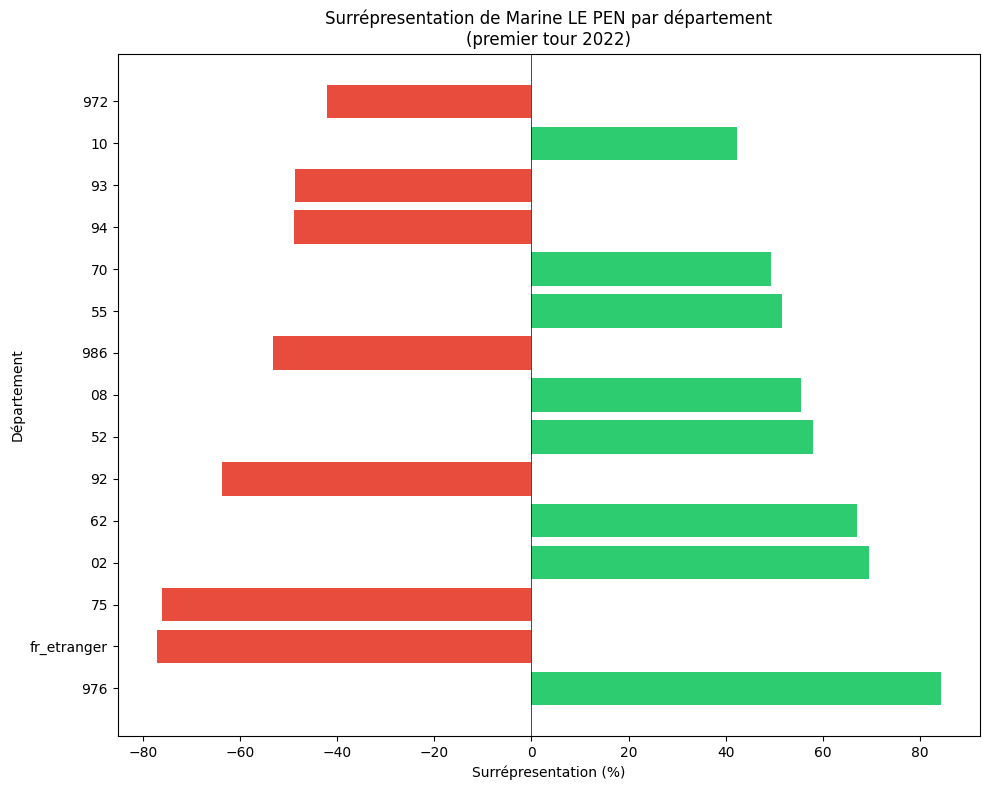

In [21]:
import matplotlib.pyplot as plt

def plot_surrepresentation(candidat, n=15):
    col_surrep = f'{candidat}_surrepresentation'
    df_candidat = score_departements[['code_departement', col_surrep]].copy()
    df_candidat = df_candidat.sort_values(col_surrep, key=abs, ascending=False).head(n)
    
    plt.figure(figsize=(10, 8))
    colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in df_candidat[col_surrep]]
    plt.barh(df_candidat['code_departement'], df_candidat[col_surrep], color=colors)
    plt.xlabel('Surrépresentation (%)')
    plt.ylabel('Département')
    plt.title(f'Surrépresentation de {candidat} par département\n(premier tour 2022)')
    plt.axvline(x=0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

# Exemple avec Marine Le Pen
plot_surrepresentation('Marine LE PEN')

## 3. Un peu de cartographie

<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Question 8
</div>
</div>
<div class="callout-body-container callout-body">

Faire une fonction permettant de restreindre `score_departements` en fonction d’un candidat. Commencer par tester sur Marine Le Pen (créer un nouvel objet, ne pas écraser `score_departements` nous allons l’utiliser à nouveau !).
Faire une jointure au fond de carte des départements et effectuer une carte de la représentation.

</div>
</div>